<a href="https://colab.research.google.com/github/alexali04/slt/blob/main/grokking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import subprocess

try:
    gpu = subprocess.run(
        ["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"],
        capture_output=True, text=True, check=True,
    ).stdout.strip()
except (FileNotFoundError, subprocess.CalledProcessError):
    gpu = "none visible — set Runtime > Change runtime type > GPU, or expect the CPU path (~1.5-3 h)"
print("gpu    ", gpu)

import torch
print("torch  ", torch.__version__)
print("cuda   ", torch.cuda.is_available())

gpu     Tesla T4, 15360 MiB
torch   2.11.0+cu128
cuda    True


In [2]:
import pathlib

REPO_URL = "https://github.com/alexali04/slt.git"
REPO_DIR = pathlib.Path("/content/slt")

if REPO_DIR.exists():
    !git -C {REPO_DIR} pull --ff-only
else:
    !git clone --quiet {REPO_URL} {REPO_DIR}

%cd {REPO_DIR}
!git log --oneline -1

/content/slt
56fc92e (HEAD -> main, origin/main, origin/HEAD) adding SLT, experiments, claude


In [3]:
USE_DRIVE = True
DRIVE_RUNS = "/content/drive/MyDrive/slt-runs"

runs = REPO_DIR / "runs"
if USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")

    target = pathlib.Path(DRIVE_RUNS)
    target.mkdir(parents=True, exist_ok=True)

    if runs.is_symlink():
        pass                                    # already pointed somewhere
    elif runs.exists() and any(runs.iterdir()):
        print(f"{runs} already holds data — leaving it where it is")
    else:
        if runs.exists():
            runs.rmdir()                        # empty, safe to replace
        runs.symlink_to(target)

print("runs ->", runs.resolve() if runs.exists() else "(created on first run)")

Mounted at /content/drive
runs -> /content/drive/MyDrive/slt-runs


In [4]:
!python -u scripts/008_grokking.py train --steps 200 --tag smoke --print-every 50 --ckpt-every 0
!python -u scripts/008_grokking.py plot --tag smoke

008 — grokking, (113 x 113) modular addition
  device        cuda
  parameters    226,816
  train / test  3,830 / 8,939 pairs (30% train)
  steps         200 (full batch, AdamW lr=0.001, wd=1.0)
  seed          0
  writing       runs/008-grokking-smoke/

/content/slt/src/slt/grokking.py:292: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return float(loss), float(accuracy)
  step      50  train  4.21e+00/0.086  test  5.49e+00/0.004  |w|   44.2   25.4 step/s  eta   0.1 min
  step     100  train  2.32e+00/0.469  test  7.85e+00/0.007  |w|   51.9   34.8 step/s  eta   0.0 min
  step     150  train  1.21e-01/1.000  test  1.43e+01/0.015  |w|   59.3   42.2 step/s  eta   0.0 min
  step     200  train  2.13e-02/1.000  test  1.64e+01/0.017  |w|   60.2   48.3 step/s  eta   0.0 min

  stopped at step 200 afte

In [5]:
!python -u scripts/008_grokking.py train --device auto

008 — grokking, (113 x 113) modular addition
  device        cuda
  parameters    226,816
  train / test  3,830 / 8,939 pairs (30% train)
  steps         40,000 (full batch, AdamW lr=0.001, wd=1.0)
  seed          0
  writing       runs/008-grokking/

/content/slt/src/slt/grokking.py:292: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return float(loss), float(accuracy)
  step     500  train  8.08e-04/1.000  test  1.84e+01/0.026  |w|   59.5   69.5 step/s  eta   9.5 min
  step   1,000  train  4.25e-06/1.000  test  2.23e+01/0.038  |w|   59.6   76.2 step/s  eta   8.5 min
  step   1,500  train  3.44e-07/1.000  test  2.32e+01/0.045  |w|   56.3   78.4 step/s  eta   8.2 min
  step   2,000  train  3.26e-07/1.000  test  2.15e+01/0.056  |w|   53.5   79.3 step/s  eta   8.0 min
  step   2,500  train  3.17e-0

008 — grokking, 4,090 recorded steps up to 40,000
  train acc >= 99% at step  140
  test  acc >= 99% at step  6,930
  grokking gap                  49.5x in steps
  final (step 40,000): train 1.0000, test 1.0000
  ||w|| peaks 60.3 at step 180, ends 30.0

  wrote figures/raw/008_grokking_curves.png
  wrote figures/diagram/008_grokking.png


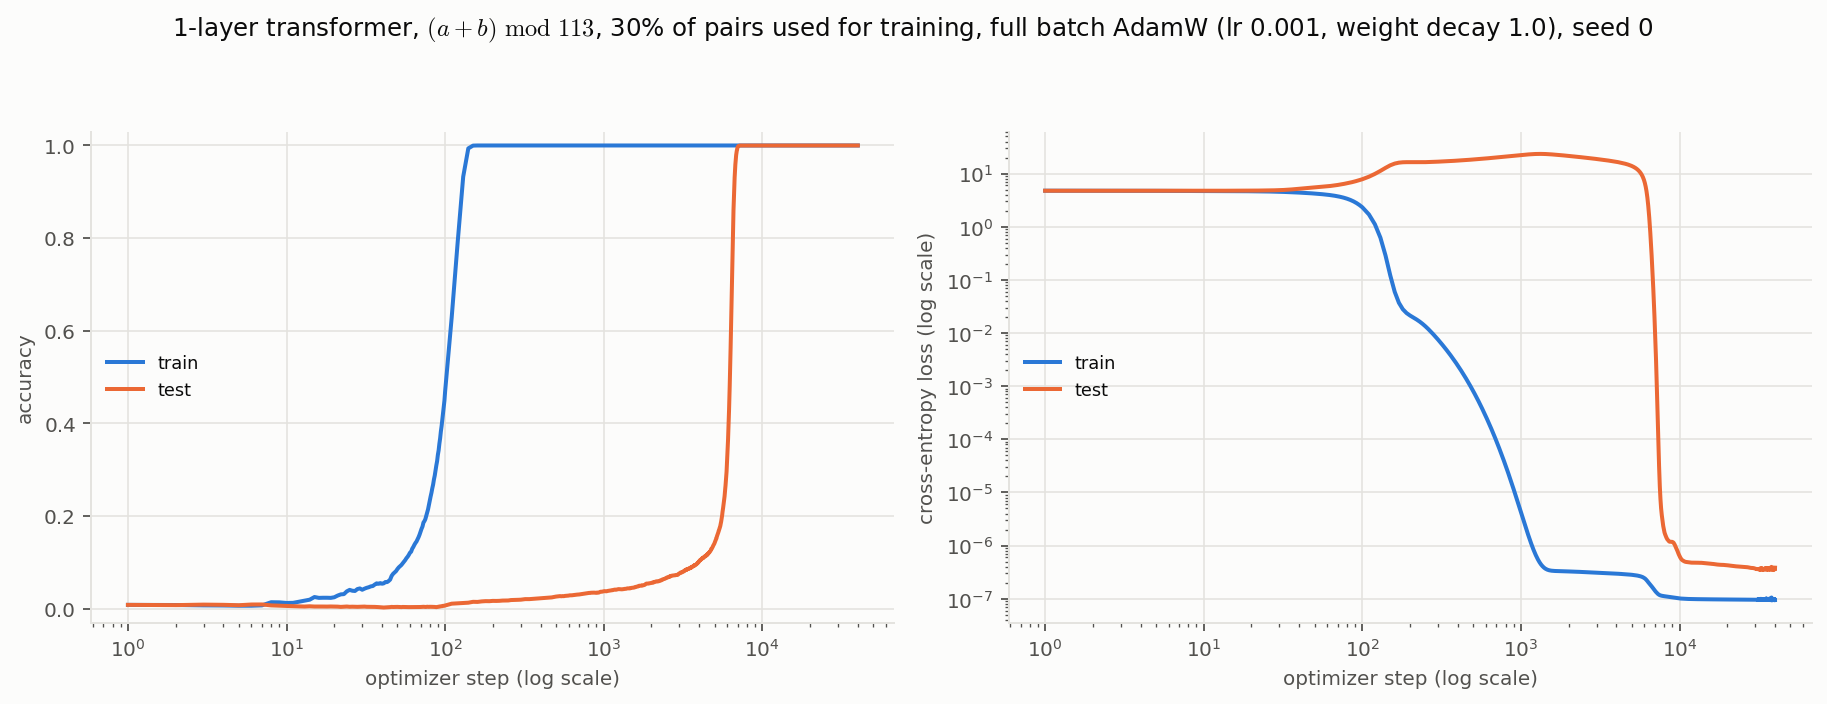

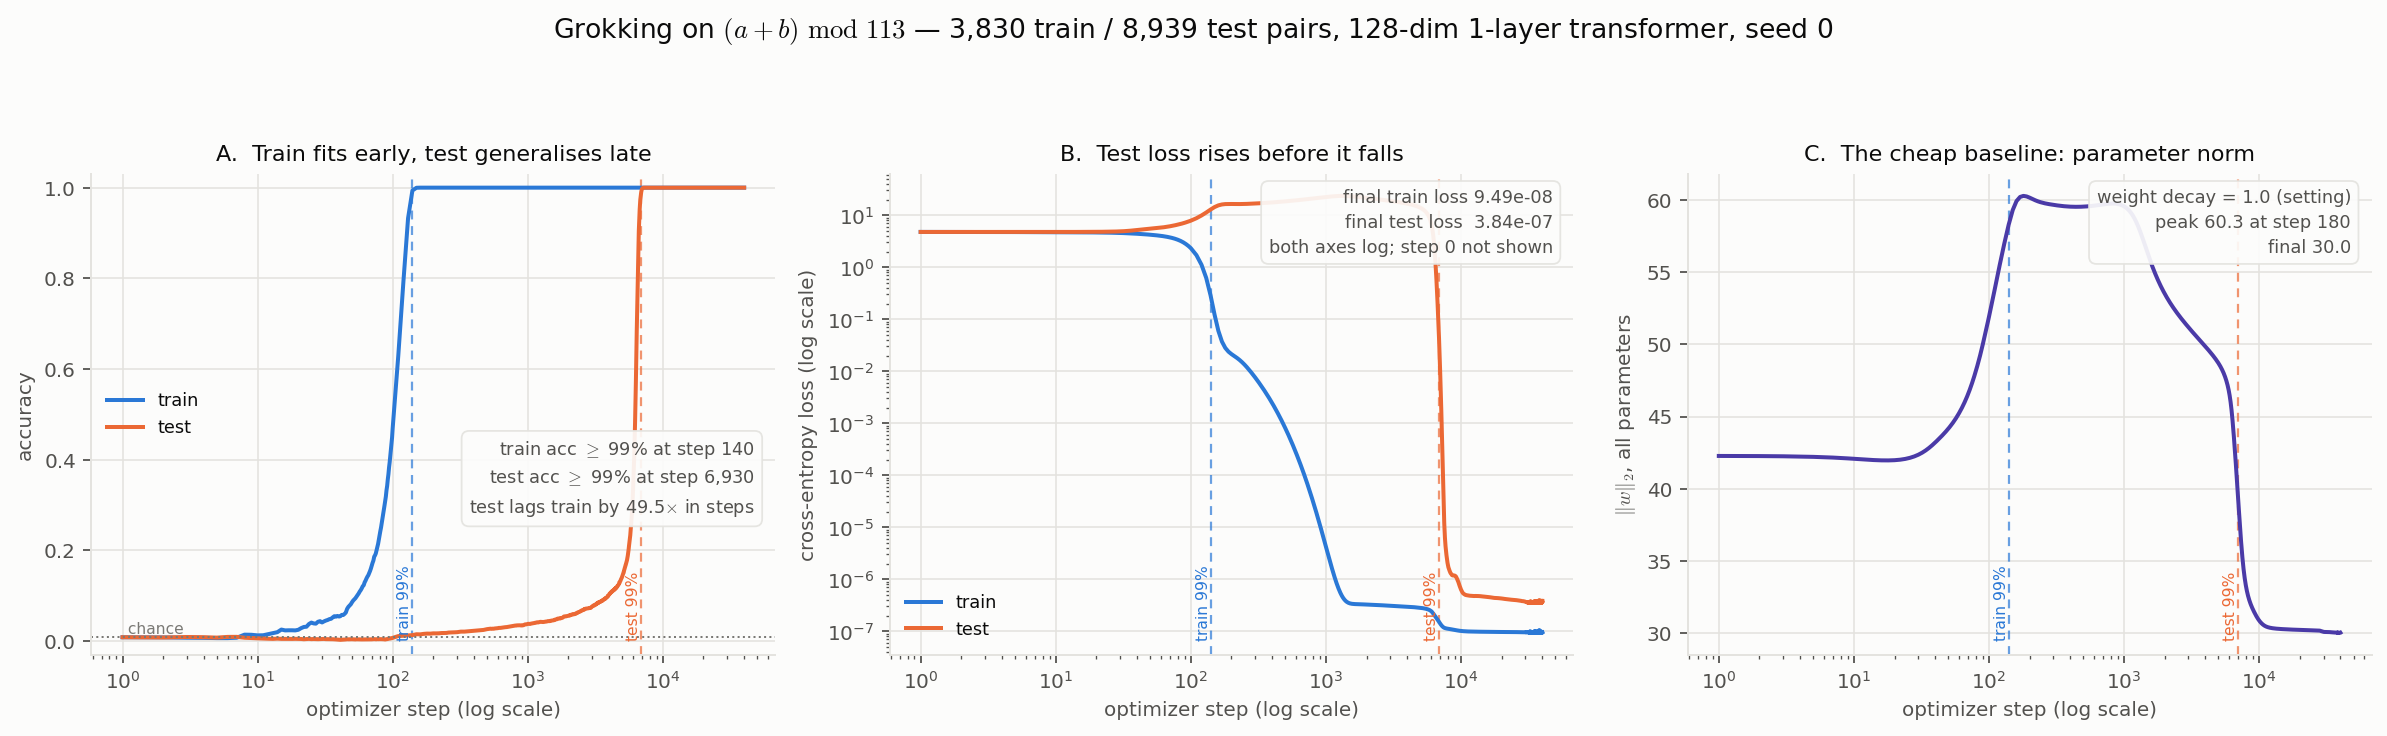

In [6]:
from IPython.display import Image, display

!python -u scripts/008_grokking.py plot

display(Image("figures/raw/008_grokking_curves.png"))
display(Image("figures/diagram/008_grokking.png"))

In [7]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	runs

nothing added to commit but untracked files present (use "git add" to track)


In [8]:
!git add runs/

fatal: pathspec 'runs/' is beyond a symbolic link
